In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


In [10]:
import pandas as pd 
df = pd.read_csv("C:\\Users\\sampada\\machine-learning-journey\\handling missing values\\imputation technique\\titanic_toy.csv")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [15]:
X = df.drop(columns=['Survived'])
y=df['Survived']

In [18]:
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size = 0.2,random_state=2)

In [21]:
X_train['Age_new'] = X_train['Age'].fillna(99)
X_train['Age_minus'] = X_train['Age'].fillna(-1)

X_train['Fare_new'] = X_train['Fare'].fillna(999)
X_train['Fare_minus'] = X_train['Fare'].fillna(-1)

In [26]:
print('Original age variable variance:',X_train['Age'].var())
print('age variance after mean imputation:',X_train['Age_new'].var())
print(' age variance after median imputation:',X_train['Age_minus'].var())
print()
print('Original fare variable variance:',X_train['Fare'].var())
print('Fare variance after mean imputation:',X_train['Fare_new'].var())
print(' Fare variance after median imputation:',X_train['Fare_minus'].var())

Original age variable variance: 204.3495133904614
age variance after mean imputation: 951.7275570187172
 age variance after median imputation: 318.0896202624484

Original fare variable variance: 2448.197913706318
Fare variance after mean imputation: 47219.20265217623
 Fare variance after median imputation: 2378.5676784883503


In [36]:

import matplotlib.pyplot as plt

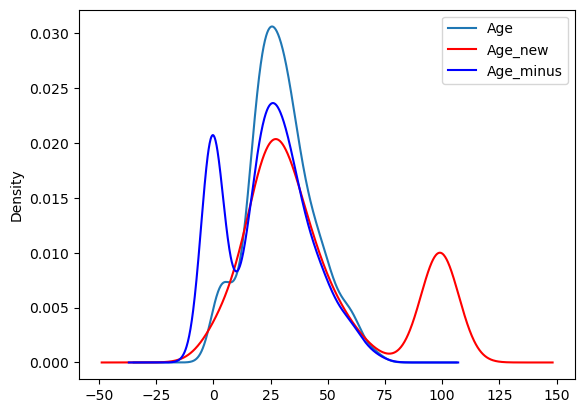

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111)
X_train['Age'].plot(kind = 'kde',ax=ax)

X_train['Age_new'].plot(kind = 'kde',ax=ax,color = 'red')

X_train['Age_minus'].plot(kind = 'kde',ax=ax , color='blue') 

lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

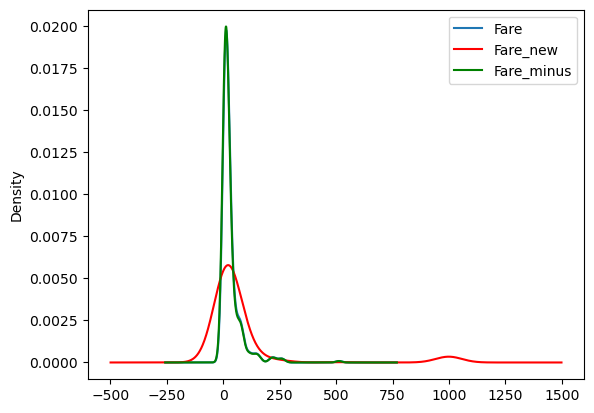

In [40]:
fig = plt.figure()
ax = fig.add_subplot(111)
X_train['Fare'].plot(kind = 'kde',ax=ax)

X_train['Fare_new'].plot(kind = 'kde',ax=ax,color = 'red')

X_train['Fare_minus'].plot(kind = 'kde',ax=ax , color='green') 

lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [42]:
X_train.cov()

,Age,Fare,Family,Age_new,Age_minus,Fare_new,Fare_minus
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,162.793430,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,11.528625,16.553989
Age_new,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-159.931663,-94.317400
Age_minus,204.349513,125.558364,-4.149246,-189.535540,318.089620,257.379887,114.394141
Fare_new,162.793430,2448.197914,11.528625,-159.931663,257.379887,47219.202652,762.474982
Fare_minus,63.321188,2448.197914,16.553989,-94.317400,114.394141,762.474982,2378.567678


In [44]:
X_train.corr()

,Age,Fare,Family,Age_new,Age_minus,Fare_new,Fare_minus
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.051179,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.032079,0.205233
Age_new,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.023857,-0.062687
Age_minus,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.066411,0.131514
Fare_new,0.051179,1.000000,0.032079,-0.023857,0.066411,1.000000,0.071946
Fare_minus,0.084585,1.000000,0.205233,-0.062687,0.131514,0.071946,1.000000
